# Tomato Plant Disease Detection Using Transfer Learning Deep Learning Project using MobileNetV2
## Author
Surojit Jana
## Objective
To develop a deep learning-based image classification system capable of identifying tomato plant diseases from leaf images using transfer learning and MobileNetV2.
---


# 1. Environment Setup

This section initializes the Google Colab environment, mounts Google Drive, and prepares the dataset for training.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Dataset Extraction

The dataset is stored as a compressed archive in Google Drive. The archive is extracted into the Colab runtime to enable efficient data loading and processing.

In [8]:
!unzip -q '/content/drive/MyDrive/tomato_dataset.zip' -d '/content/tomato_dataset'

# 3. Import Required Libraries

This section imports all required Python libraries for dataset processing, visualization, model development, training, and evaluation.

# 3A. imports for Model Training

In [9]:

import tensorflow as tf
import keras
from keras import layers
from keras.applications import MobileNetV2


# 3B. imports for Data Analysis & Visualization

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 4. Dataset Verification

Before training the model, the dataset structure is verified to ensure that training, validation, and testing directories are correctly configured.

In [11]:
import os

print(os.listdir('/content/tomato_dataset'))

train_dir = '/content/tomato_dataset/train'
validation_dir = '/content/tomato_dataset/validation'
test_dir = '/content/tomato_dataset/test'

print('Number of classes inside train:', len(os.listdir(train_dir)))
print('Number of classes inside train:', len(os.listdir(validation_dir)))
print('Number of classes inside train:', len(os.listdir(test_dir)))

['test', 'train', 'validation']
Number of classes inside train: 10
Number of classes inside train: 10
Number of classes inside train: 10


# 5. Dataset Loading

Images are loaded using TensorFlow's image_dataset_from_directory() utility. Images are resized to 224×224 pixels to match MobileNetV2 input requirements.

In [12]:
from pathlib import Path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET_DIR = Path('/content/tomato_dataset')

train_dir = DATASET_DIR / 'train'
validation_dir = DATASET_DIR / 'validation'
test_dir = train_dir = DATASET_DIR / 'test'

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = 'categorical'
)

val_ds = keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = 'categorical'
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = 'categorical',
    shuffle = False
)

Found 1610 files belonging to 10 classes.
Found 3198 files belonging to 10 classes.
Found 1610 files belonging to 10 classes.


# 6. Dataset Information

This section displays the disease categories and verifies the number of classes available for classification.

In [13]:
class_names = train_ds.class_names
num_classes = len(class_names)

print('Number of Classes:', num_classes)
print('Class Nmaes:')
for i, name in enumerate(class_names):
  print(i, name)


Number of Classes: 10
Class Nmaes:
0 Tomato__Bacterial_Spot
1 Tomato__Early_Blight
2 Tomato__Healthy
3 Tomato__Late_Blight
4 Tomato__Leaf_Mold
5 Tomato__Mosaic_Virus
6 Tomato__Septoria_Leaf_Spot
7 Tomato__Target_Spot
8 Tomato__Two_Spotted_Spider_Mites
9 Tomato__YellowLeaf_Curl_Virus


# 7. Dataset Optimization

Dataset prefetching is used to improve training performance by overlapping preprocessing and model execution.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# 8. Data Augmentation

Data augmentation is applied only to the training data to improve model generalization and reduce overfitting.

Techniques Used:
- Horizontal Flip
- Rotation
- Zoom
- Translation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),      # Randomly flip image left-right
    layers.RandomRotation(0.1),           # Rotate image by ±10%
    layers.RandomZoom(0.1),               # Randomly zoom in/out by 10%
    layers.RandomTranslation(0.1, 0.1)    # Shift image horizontally/vertically by 10%
], name="data_augmentation")

## 9. Check Batch Shape

In [ ]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 10)


## 10. Visualize a Batch

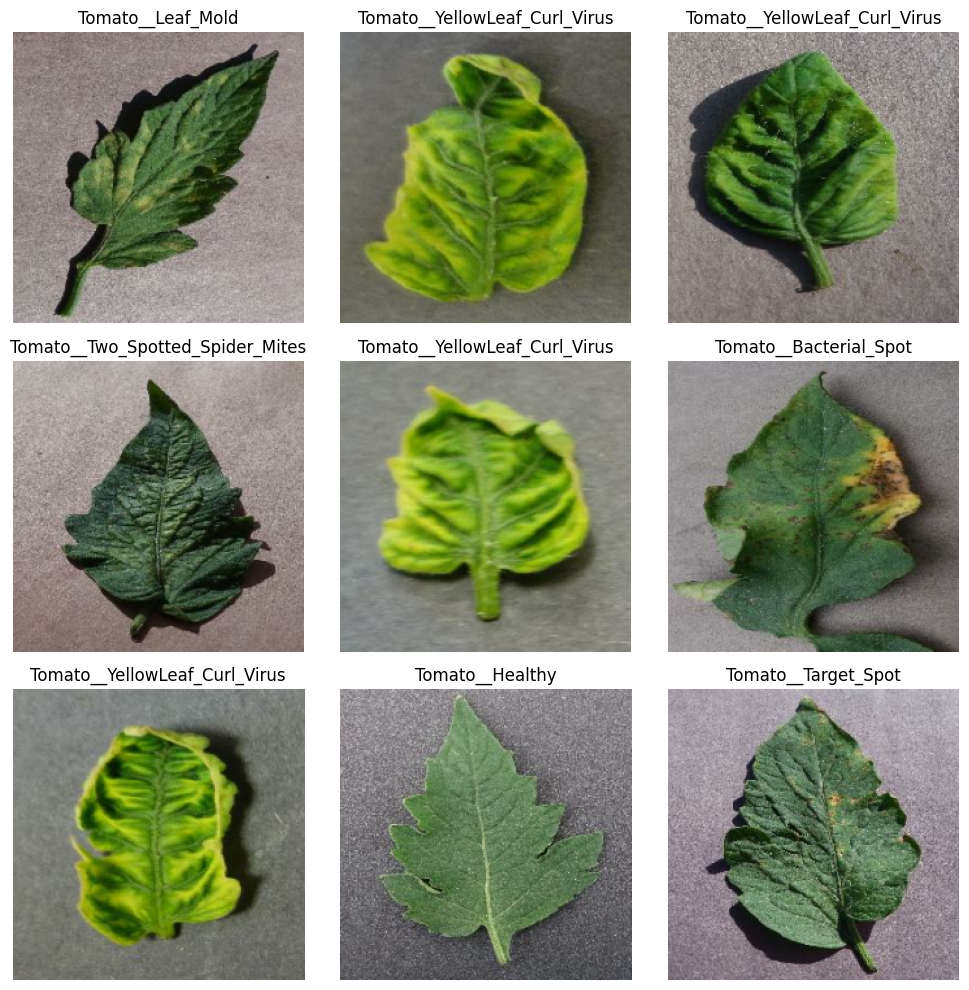

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = labels[i].numpy().argmax()

        plt.title(class_names[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

# 11. MobileNetV2 Feature Extractor (Transfer Learning)

In this project, MobileNetV2 is used as a pretrained feature extractor through Transfer Learning.

##  Why MobileNetV2?

Training a deep Convolutional Neural Network (CNN) from scratch requires a very large dataset and significant computational resources. Instead, we use MobileNetV2, which has already been trained on the ImageNet dataset containing millions of images across 1000 categories.

The pretrained model has already learned important visual features such as:

- Edges
- Shapes
- Textures
- Patterns
- Color variations

These features are also useful for identifying tomato plant diseases.

---

## Removing original MobileNetV2 Classifier
```python
include_top = Flase
```
The original MobileNetV2 model contains a classifier that predicts 1000 ImageNet classes such as dogs, cars, birds, etc.

Since this project focuses on tomato disease classification, the original classifier is removed and only the feature extraction layers are retained.


## Retaining Random Weights learnt from imagenet

```python
weights = 'imagenet'
```
This loads the pretrained weights learned from the ImageNet dataset.

Using pretrained weights allows the model to start with rich visual knowledge instead of random weights, resulting in:

- Faster training
- Better convergence
- Improved accuracy
- Reduced data requirements


##  Freezing the Base Model

```python
base_model.trainable = Flase
```

Initially, all MobileNetV2 layers are frozen.

This means:

- Pretrained weights remain unchanged.
- Only the newly added classification layers are trained.
- Training becomes faster and more stable.
- Risk of overfitting is reduced.

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# 12. Custom Classification Head

After extracting image features using the pretrained MobileNetV2 model, a custom classification head is added to perform tomato disease classification.

The purpose of this section is to transform the high-level image features generated by MobileNetV2 into probabilities for the 10 tomato disease categories.

---

## Model Architecture

```text
Input Image (224×224×3)
            │
            ▼
Data Augmentation
            │
            ▼
MobileNetV2
(Pretrained Feature Extractor)
            │
            ▼
GlobalAveragePooling2D
            │
            ▼
Dense Layer (128 Neurons)
            │
            ▼
Dropout (0.3)
            │
            ▼
Dense Layer (10 Neurons)
            │
            ▼
Softmax
            │
            ▼
Disease Prediction
```

---

## GlobalAveragePooling2D

```python
layers.GlobalAveragePooling2D()
```

The output of MobileNetV2 is a set of feature maps.

Global Average Pooling converts these feature maps into a compact feature vector by calculating the average value of each feature map.

Benefits:

* Reduces the number of trainable parameters.
* Helps prevent overfitting.
* Improves computational efficiency.
* Commonly used in transfer learning architectures.

---

## Dense Layer

```python
layers.Dense(128, activation="relu")
```

The dense layer learns disease-specific patterns from the features extracted by MobileNetV2.

The ReLU activation function introduces non-linearity and enables the network to learn complex relationships between image features and disease categories.

Why 128 neurons?

* Sufficient capacity for learning disease features.
* Computationally efficient.
* Reduces risk of overfitting compared to larger layers.

---

## Dropout Layer

```python
layers.Dropout(0.3)
```

Dropout randomly disables 30% of neurons during training.

Purpose:

* Reduces overfitting.
* Improves generalization.
* Prevents the model from memorizing training samples.

The dropout layer is active only during training and is automatically disabled during inference.

---

## Output Layer

```python
layers.Dense(10, activation="softmax")
```

The output layer contains 10 neurons, corresponding to the 10 tomato disease classes.

The Softmax activation function converts raw outputs into probability values between 0 and 1.

Example:

```text
Healthy                     0.01
Early Blight                0.03
Late Blight                 0.02
Leaf Mold                   0.90
```

The class with the highest probability is selected as the final prediction.

---

## Purpose in This Project

The MobileNetV2 base model extracts visual features such as:

* Leaf texture
* Disease spots
* Color variations
* Lesion patterns

The custom classification head learns how these features correspond to the 10 tomato disease categories and produces the final prediction.


In [ ]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

# 13. Model Summary

The following summary displays the architecture, trainable parameters, and non-trainable parameters of the proposed model.

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 14. Model Compilation

The model is compiled using:

- Optimizer: Adam
- Learning Rate: 0.001
- Loss Function: Categorical Crossentropy
- Metric: Accuracy

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 15. Training Configuration

To improve training reliability and reduce overfitting, two callback mechanisms are used:

- Early Stopping
- Model Checkpointing
- Reducing Learning Rate

## Early Stopping
Terminates training when validation performance stops improving.

## Model Checkpointing
Saves the best-performing model during training.

## Reducing Learning Rate
If validtation loss stalls, training becomes more refined

# 15A. Creating a model folder
At the end we will save:
```
best_model.keras
final_model.keras
training_history.pkl
```
inside this folder

In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/tomato_disease_model"

os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_DIR

'/content/drive/MyDrive/tomato_disease_model'

# 15B. Model Chekpoint

## Understanding the parameters
### monitor
```python
monitor = 'val_accuracy'
```
Watches validation accuracy

### saves_best_only
```python
saves_best_only = True
```
Only saves better models

### Mode
```python
mode = 'max'
```
Higher accuracy is better


In [ ]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=f"{MODEL_DIR}/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# 15C. Early Stopping

## Understanding the parameters

### monitor
```python
monitor = 'val_loss'
```
The callback watches the validation loss closely after every epoch. This is necessary for generalization of the model

### patience
```python
patience = 5
```
Waits 5 consecutive epochs of zero improvement before stopping,
if validation loss improves on the 5th epoch, the countdown timer resets

Example:
```
Epoch 5  no improvement
Epoch 6  no improvement
Epoch 7  no improvement
Epoch 8  no improvement
Epoch 9  no improvement
```
Stop training

### restore_best_weights
```python
restore_best_weights = True
```
Ensures the model finishes its training with its absolute best version, rather thann the version from the final epoch

## verbose
```python
verbose=1
```
It prints a clear message in the terminal console every single time it lowers the learning rate, so you know exactly what is happening during training

In [ ]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 15.D Reduce Learning Rate

## Understanding the parameters

### factor
```python
factor=0.2
```
When it decides to drop the learning rate, it multiplies the current learning rate by 0.2 (cutting it down by 80%). For example, a learning rate of 0.001 becomes 0.0002

### min_lr
```python
min_lr=1e-6
```
This sets a hard floor (0.000001). The learning rate will never drop below this number, preventing it from shrinking to zero and stopping learning entirely


In [ ]:
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# 15E. Combining Callbacks

In [ ]:
callback_list = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback
]

callback_list

# 16. Model Training

The classifier head is trained while keeping the MobileNetV2 feature extractor frozen.

This phase is known as Feature Extraction Training.

In [ ]:
EPOCH_SIZE = 16

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH_SIZE,
    callbacks=callback_list
)

Epoch 1/16
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3365 - loss: 2.0286
Epoch 1: val_accuracy improved from None to 0.69919, saving model to /content/drive/MyDrive/tomato_disease_model/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/tomato_disease_model/best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.4708 - loss: 1.6014 - val_accuracy: 0.6992 - val_loss: 0.9995 - learning_rate: 0.0010
Epoch 2/16
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6515 - loss: 1.0530
Epoch 2: val_accuracy improved from 0.69919 to 0.75297, saving model to /content/drive/MyDrive/tomato_disease_model/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/tomato_disease_model/best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.6870 - loss: 0.9516 - val_accuracy: 0.7530 - val_loss: 0.7624 - learning_rate: 0.0010
Epoch 3/16
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7219 - loss: 0.8208
Epoch 

# 17. Training Performance Analysis

Training and validation accuracy/loss curves are plotted to evaluate model learning behavior and identify potential overfitting.

# 17A. Visualization of Accuracy Curves

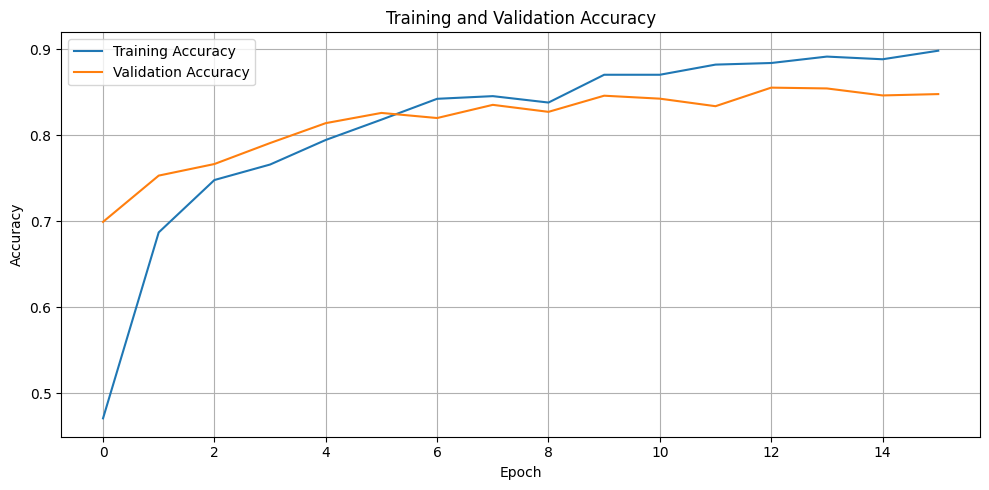

In [ ]:

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/tomato_disease_model/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 17B. Visualization of Loss Curves

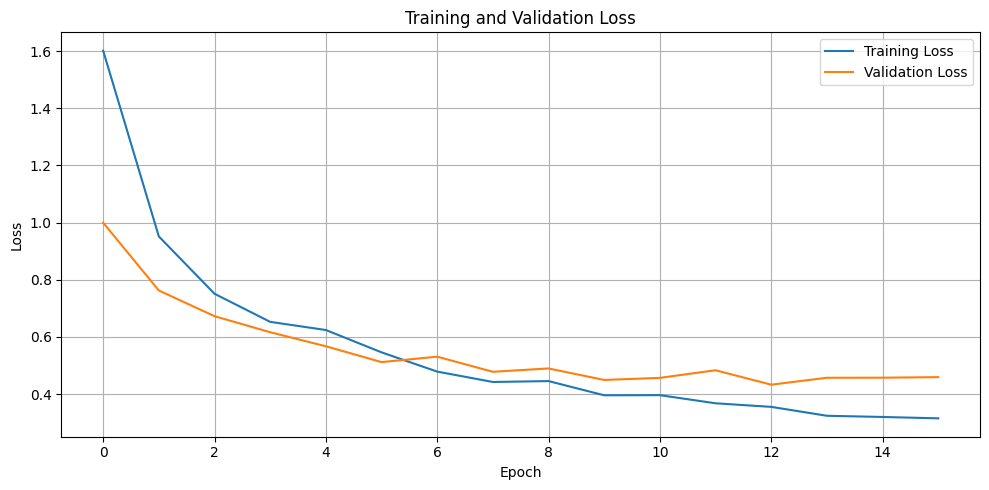

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/tomato_disease_model/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 17C. Performance Summary Table

In [ ]:
train_accuracy, train_loss, val_accuracy, val_loss, _ = [round(history.history[key][-1], 4) for key in history.history]
best_val_accuracy = max(history.history['val_accuracy'])
train_accuracy, val_accuracy, best_val_accuracy = [round(v * 100, 2) for v in (train_accuracy, val_accuracy, best_val_accuracy)]

# for key in history.history:
#   print(key, ': ', [round(val * 100,4) for val in history.history[key]])

performance_summary = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Final Training Loss",
        "Final Validation Loss"
    ],
    "Value": [
        best_val_accuracy,
        train_accuracy,
        val_accuracy,
        train_loss,
        val_loss
    ]
})

performance_summary.to_csv(
    "/content/drive/MyDrive/tomato_disease_model/performance_summary.csv",
    index=False
)

performance_summary



,Metric,Value
0,Best Validation Accuracy,85.5200
1,Final Training Accuracy,89.8100
2,Final Validation Accuracy,84.7700
3,Final Training Loss,0.3150
4,Final Validation Loss,0.4592


# 18. Model Evaluation

The trained model is evaluated using the test dataset.

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

# 18A. Load the best model and evaluate on test data for model evaluation

In [ ]:
# loading best model
best_model = keras.models.load_model(
    "/content/drive/MyDrive/tomato_disease_model/best_model.keras"
)

# evaluating on test dataset
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9087 - loss: 0.2754
Test Loss: 0.2754
Test Accuracy: 0.9087


# 18B. Generate Predictions

In [ ]:
y_true = np.concatenate(
    [labels.numpy() for _, labels in test_ds]
)

y_true = np.argmax(y_true, axis=1)

predictions = best_model.predict(test_ds)

y_pred = np.argmax(predictions, axis=1)

51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step


# 18C. Classification Report

Classfication report includes:
- Precision
- Recall
- F1-score
- Support

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# print(report)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    "/content/drive/MyDrive/tomato_disease_model/classification_report.csv"
)

report_df

,precision,recall,f1-score,support
Tomato__Bacterial_Spot,0.875000,0.981308,0.925110,214.000000
Tomato__Early_Blight,0.850575,0.740000,0.791444,100.000000
Tomato__Healthy,0.923077,0.975000,0.948328,160.000000
Tomato__Late_Blight,0.988571,0.901042,0.942779,192.000000
Tomato__Leaf_Mold,0.908163,0.927083,0.917526,96.000000
Tomato__Mosaic_Virus,1.000000,0.605263,0.754098,38.000000
Tomato__Septoria_Leaf_Spot,0.929825,0.893258,0.911175,178.000000
Tomato__Target_Spot,0.894737,0.718310,0.796875,142.000000
Tomato__Two_Spotted_Spider_Mites,0.747706,0.970238,0.844560,168.000000
Tomato__YellowLeaf_Curl_Virus,0.996825,0.975155,0.985871,322.000000


# 18D. Confusion Matrix

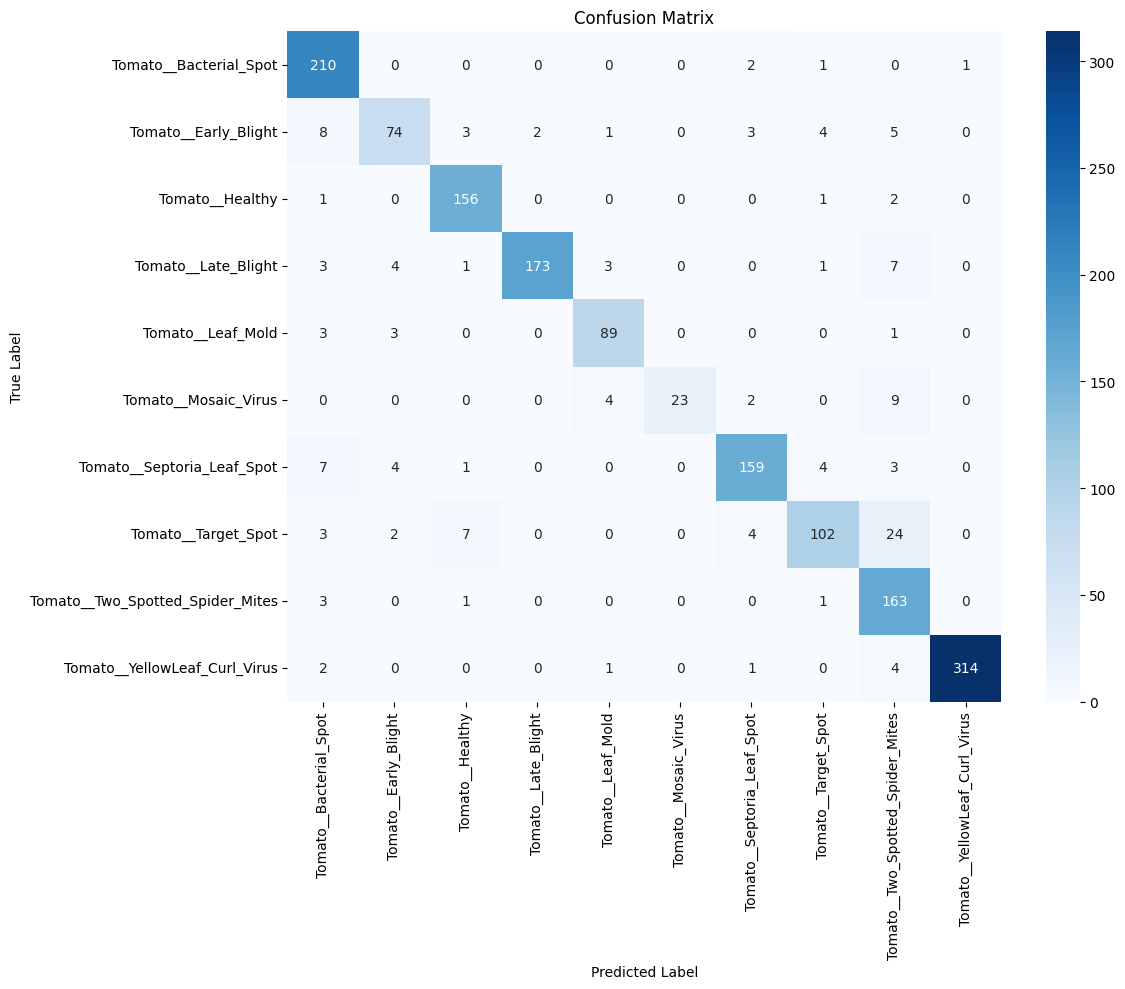

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/tomato_disease_model/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# 19. Conclusion

The MobileNetV2-based transfer learning model was successfully trained to classify ten tomato disease categories.

The results demonstrate the effectiveness of transfer learning for agricultural disease detection tasks.

# 20. Fine-Tuning

In this phase, selected upper layers of the MobileNetV2 base model are unfrozen and trained using a very small learning rate. This allows the pretrained feature extractor to adapt more specifically to tomato disease image features while preserving the general visual knowledge learned from ImageNet.

# Step 1: Load Best Baseline Model

In [ ]:
model = keras.models.load_model(
    "/content/drive/MyDrive/tomato_disease_model/best_model.keras"
)

# Step 2: Unfreeze MobileNetV2 partially

In [ ]:
base_model = model.get_layer("mobilenetv2_1.00_224")

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Step 3: Recompile with very low learning rate

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Step 4: Create fine-tuning callbacks

In [ ]:
fine_tune_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/tomato_disease_model/fine_tuned_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

fine_tune_early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

fine_tune_callbacks = [
    fine_tune_checkpoint,
    fine_tune_early_stop,
    fine_tune_reduce_lr
]

# Step 5: Train again

In [ ]:
FINE_TUNE_EPOCHS = 16

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/16
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4978 - loss: 1.8229
Epoch 1: val_accuracy improved from None to 0.85741, saving model to /content/drive/MyDrive/tomato_disease_model/fine_tuned_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/tomato_disease_model/fine_tuned_best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 299ms/step - accuracy: 0.5596 - loss: 1.5871 - val_accuracy: 0.8574 - val_loss: 0.4322 - learning_rate: 1.0000e-05
Epoch 2/16
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6564 - loss: 1.1037
Epoch 2: val_accuracy improved from 0.85741 to 0.86179, saving model to /content/drive/MyDrive/tomato_disease_model/fine_tuned_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/tomato_disease_model/fine_tuned_best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.6807 - loss: 0.9961 - val_accuracy: 0.8618 - val_loss: 0.4218 - learning_rate: 1.0000e-05
Epoch 3/16
50/51 ━━━━━━━━━━━━━━━━━━━━ 0

# 21. Evaluation of Fine-tuned Model

In [ ]:
fine_tuned_model = keras.models.load_model(
    "/content/drive/MyDrive/tomato_disease_model/fine_tuned_best_model.keras"
)

test_loss, test_accuracy = fine_tuned_model.evaluate(test_ds)

print(f"Fine-Tuned Test Loss: {test_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {test_accuracy:.4f}")

NameError: name 'test_ds' is not defined

# 21A. Generate Predictions using Fine-tuned Model

In [ ]:
y_true = np.concatenate(
    [labels.numpy() for _, labels in test_ds]
)

y_true = np.argmax(y_true, axis=1)

predictions = fine_tuned_model.predict(test_ds)

y_pred = np.argmax(predictions, axis=1)

51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step


# 21B. Fine-tuned Classification Report

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# print(report)
report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "/content/drive/MyDrive/tomato_disease_model/fine_tuned_classification_report.csv"
)

report_df

NameError: name 'classification_report' is not defined

# 21C. Fine-tuned Confusion Matrix

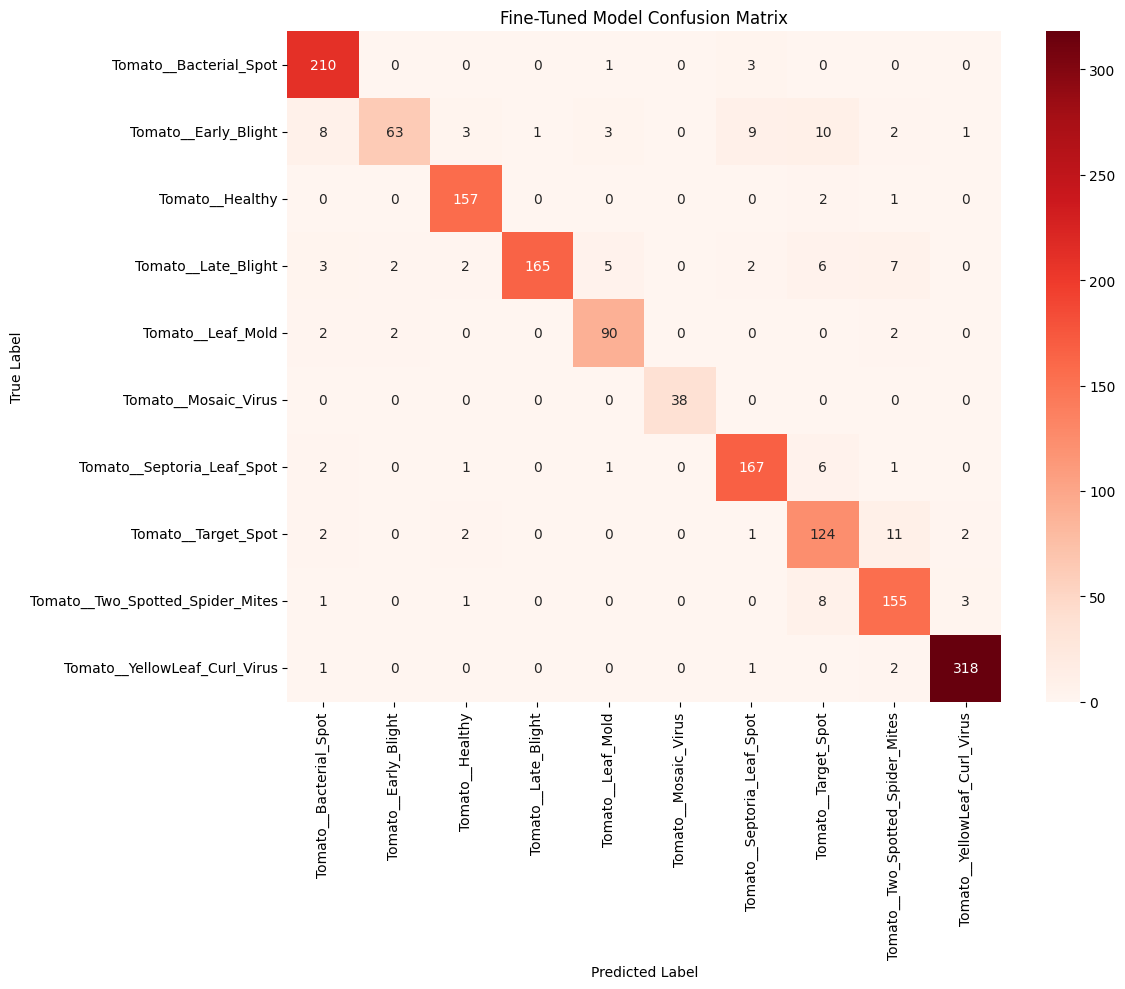

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names

)

plt.title('Fine-Tuned Model Confusion Matrix')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/tomato_disease_model/fine_tuned_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 22. Conclusion

Fine-tuning the upper layers of MobileNetV2 improved the overall performance of the proposed tomato disease detection system. Test accuracy increased from 91.55% to 92.36%, while the weighted F1-score improved from 91.48% to 92.22%. The most notable improvement was observed for Tomato Mosaic Virus, where recall increased from 52.6% to 100%, demonstrating the effectiveness of fine-tuning in improving minority-class detection. Although slight reductions were observed for Early Blight and Late Blight, the overall model performance improved substantially, making the fine-tuned model the preferred choice for deployment.


# 23. Saving the Fine Tuned Model

In [ ]:
final_model_path = '/content/drive/MyDrive/tomato_disease_model/final_tomato_disease_model.keras'
fine_tuned_model.save(final_model_path)

print('Final Model saved successfully')

Final Model saved successfully


# Saving the Class Names in JSON format

In [ ]:
import json

class_names_path = '/content/drive/MyDrive/tomato_disease_model/class_names.json'

with open(class_names_path, 'w') as f:
  json.dump(class_names, f)

print('Class names saved successfully')

Class names saved successfully


# Validating Prediction

In [ ]:
from PIL import Image
import numpy as np
import json

image_path = "/content/tomato_dataset/test/Tomato__Bacterial_Spot/01f13167-f508-4ef2-8720-4e973438f8fc___GCREC_Bact.Sp 5892.JPG"

img = Image.open(image_path).convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img).astype("float32")
img_array = np.expand_dims(img_array, axis=0)

with open('/content/drive/MyDrive/tomato_disease_model/class_names.json', 'r') as f:
  class_names = json.load(f)
fine_tuned_model = keras.models.load_model('/content/drive/MyDrive/tomato_disease_model/final_tomato_disease_model.keras')
predictions = fine_tuned_model.predict(img_array)[0]

predicted_index = np.argmax(predictions)
confidence = predictions[predicted_index] * 100

print('Predicted Category:', class_names[predicted_index])
print('Confidence:', confidence)

for i in np.argsort(predictions)[::-1]:
    print(i, class_names[i], predictions[i] * 100)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Category: Tomato__Bacterial_Spot
Confidence: 94.88071
0 Tomato__Bacterial_Spot 94.88071
6 Tomato__Septoria_Leaf_Spot 5.070879
1 Tomato__Early_Blight 0.022992343
7 Tomato__Target_Spot 0.015407297
9 Tomato__YellowLeaf_Curl_Virus 0.0038743047
4 Tomato__Leaf_Mold 0.0034552496
8 Tomato__Two_Spotted_Spider_Mites 0.0016050544
3 Tomato__Late_Blight 0.0005209389
5 Tomato__Mosaic_Virus 0.0004309005
2 Tomato__Healthy 0.00013415293
